# Avance 2 — Análisis Completo
## Variabilidad en el Tratamiento Oncológico y sus Efectos sobre la Mortalidad
## y la Estadía Hospitalaria en el Sistema Público Chileno

**Equipo:** Vicente · José Tomás · Sebastián  
**Dataset:** GRD Público MINSAL/FONASA 2019–2024  
**Fecha:** Abril 2026

---

### Pregunta de Investigación
> ¿En qué medida el hospital de atención determina los días de estadía, la cantidad de procedimientos
> y la mortalidad intrahospitalaria en pacientes oncológicos clínicamente comparables?

### Hipótesis
| | |
|--|--|
| **H₀** | No existe diferencia estadísticamente significativa en los días de estadía entre hospitales para pacientes oncológicos con severidad comparable. |
| **H₁** | Existe variabilidad significativa en los días de estadía entre hospitales, atribuible al establecimiento y no a la severidad clínica del paciente. |

### Modelo
| Rol | Variable | Columna GRD |
|-----|----------|-------------|
| **Independiente** | Hospital | `COD_HOSPITAL` |
| **Dependiente 1** | Días de estadía | `FECHAALTA − FECHA_INGRESO` |
| **Dependiente 2** | Cantidad de procedimientos | `PROCEDIMIENTO1..30` (conteo) |
| **Dependiente 3** | Mortalidad intrahospitalaria | `TIPOALTA == 'FALLECIDO'` |
| **Control** | Diagnóstico oncológico CIE-10 | `DIAGNOSTICO1` |
| **Control** | Peso GRD (severidad) | `IR_29301_PESO` |
| **Control** | Edad | calculada |
| **Control** | Sexo | `SEXO` |


## Instrucciones

1. Coloca los archivos `GRD_PUBLICO_{año}.csv` (separador `|`) en la carpeta `DATASET-PROBLEMA8/` junto a este notebook, **o** ajusta la variable `DATA_DIR` en la siguiente celda.
2. Ejecuta **Kernel → Restart & Run All**.
3. Los gráficos se guardan en `outputs/graficos/` y las tablas en `outputs/tablas/` (se crean automáticamente).

> **Sin datos disponibles:** el notebook igual ejecuta todas las celdas y mostrará mensajes claros indicando qué archivos faltan.


---
## 0. Configuración
Todos los parámetros ajustables están en esta celda.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURACIÓN — ajusta aquí si es necesario               ║
# ╚══════════════════════════════════════════════════════════════╝
from pathlib import Path

# Ruta a la carpeta con los CSV GRD (relativa al notebook)
DATA_DIR  = Path('..') / 'DATASET INICIAL'
UTF8_DIR  = DATA_DIR / 'utf8'

# Mapeo comunas-regiones
COMUNAS_REGIONES_JSON = DATA_DIR / 'comunas-regiones.json'

# Carpetas de salida (se crean solas)
OUT_GRAFICOS = Path('outputs') / 'graficos'
OUT_TABLAS   = Path('outputs') / 'tablas'
OUT_GRAFICOS.mkdir(parents=True, exist_ok=True)
OUT_TABLAS.mkdir(parents=True, exist_ok=True)

# Archivo de códigos oncológicos CIE-10
CODIGOS_ONCO_TXT = Path('..') / 'codigos_C00_D49.txt'

# Años a cargar
ANIOS = [2019, 2020, 2021, 2022, 2023, 2024]

# Diagnóstico focal CIE-10 para el análisis bivariado (sección 4.2)
# C16.* = Tumor Maligno del Estómago (Cáncer Gástrico) — todos los subtipos
# Nota: TARGET_GRD se mantiene por compatibilidad histórica pero ya no se usa como filtro principal
TARGET_GRD = '597'   # Reemplazado por TARGET_CIE en sección 4.2 (CIE-10 C16.*)

# Mínimo de casos por hospital para análisis inferencial
MIN_CASOS_HOSPITAL = 20

# Top N hospitales en gráficos
TOP_N = 15

# Percentil para corte de outliers en días de estadía
P_OUTLIER = 0.99

print('Configuración cargada.')
print(f'DATA_DIR  → {DATA_DIR.resolve()}')
print(f'Salidas   → {OUT_GRAFICOS.resolve()}')
print(f'Mapa comunas-regiones → {COMUNAS_REGIONES_JSON.resolve()}')

---
## 1. Librerías


In [33]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas:', pd.__version__, np.__version__)


Librerías cargadas: 2.2.3 2.1.3


---
## 2. Carga y Preparación de Datos

### 2.1 Funciones auxiliares
Todas las funciones están definidas aquí para que el notebook sea completamente autocontenido.


In [34]:
# ── Detección robusta de columnas (los CSV cambian nombre entre años) ──────
import json
import unicodedata

def elegir_col(df, candidatos, etiqueta):
    """Devuelve el nombre real de la primera columna que coincida con algún candidato."""
    mapa = {c.lower().strip(): c for c in df.columns}
    for c in candidatos:
        if c.lower().strip() in mapa:
            return mapa[c.lower().strip()]
    raise KeyError(
        f"No se encontró columna para '{etiqueta}'.\n"
        f"Candidatas: {candidatos}\n"
        f"Columnas del archivo: {list(df.columns)}"
    )

# ── Lectura de un CSV GRD (prueba encodings y fallback de parser) ───────────
def leer_csv_grd(path):
    if not path.exists():
        return None

    for enc in ('utf-8', 'latin-1', 'cp1252', 'utf-16', 'utf-16-le'):
        try:
            try:
                df = pd.read_csv(path, sep='|', encoding=enc, low_memory=False)
            except pd.errors.ParserError:
                # Fallback para archivos con filas irregulares
                df = pd.read_csv(
                    path, sep='|', encoding=enc, engine='python', on_bad_lines='skip'
                )

            df['_archivo'] = path.name
            return df
        except UnicodeDecodeError:
            continue
    return None

# ── Parseo robusto de fechas por año/fuente ─────────────────────────────────
def parsear_fecha(serie, anio_serie=None, formato_default='%Y-%m-%d'):
    serie_txt = serie.astype(str).str.strip()

    if anio_serie is not None:
        anio_txt = anio_serie.astype(str)
        mask_2023 = anio_txt.eq('2023')

        parsed_2023 = pd.to_datetime(
            serie_txt.where(mask_2023), format='%d-%m-%Y', errors='coerce'
        )
        parsed_otros = pd.to_datetime(
            serie_txt.where(~mask_2023), format=formato_default, errors='coerce'
        )
        parsed = parsed_2023.fillna(parsed_otros)
    else:
        parsed = pd.to_datetime(serie_txt, format=formato_default, errors='coerce')

    # Fallback final para formatos mixtos o sucios
    fallback_mixed = pd.to_datetime(
        serie_txt, format='mixed', dayfirst=True, errors='coerce'
    )
    return parsed.fillna(fallback_mixed)

# ── Utilidades para mapeo comuna -> region ──────────────────────────────────
def normalizar_texto(txt):
    if txt is None or pd.isna(txt):
        return None
    txt = str(txt).strip().lower()
    txt = ''.join(
        c for c in unicodedata.normalize('NFKD', txt) if not unicodedata.combining(c)
    )
    txt = re.sub(r'\s+', ' ', txt)
    return txt

def cargar_mapa_comuna_region(path_json):
    if not path_json.exists():
        print(f'Advertencia: no se encontró {path_json}. Región quedará como nula.')
        return {}

    with open(path_json, encoding='utf-8') as f:
        payload = json.load(f)

    mapa = {}
    duplicadas = set()
    for bloque in payload.get('regiones', []):
        region = bloque.get('region')
        for comuna in bloque.get('comunas', []):
            key = normalizar_texto(comuna)
            if key in mapa and mapa[key] != region:
                duplicadas.add(comuna)
                continue
            mapa[key] = region

    if duplicadas:
        print(
            f'Advertencia: {len(duplicadas)} comunas con nombre repetido en múltiples regiones.'
        )
    print(f'Mapa comuna-región cargado: {len(mapa):,} comunas')
    return mapa

def moda_serie(s):
    s_valid = s.dropna()
    if s_valid.empty:
        return pd.NA
    return s_valid.mode().iloc[0]

print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


In [35]:
# ── Cargar dataset limpio si existe; si no, concatenar CSV GRD 2019-2024 ────
ruta_limpio = None
candidatos_limpio = [
    DATA_DIR / 'GRD_Limpio.csv',
    UTF8_DIR / 'GRD_Limpio.csv',
]

for cand in candidatos_limpio:
    if cand.exists():
        ruta_limpio = cand
        break

if ruta_limpio is None and DATA_DIR.exists():
    encontrados = sorted(DATA_DIR.rglob('GRD_Limpio.csv'))
    if encontrados:
        ruta_limpio = encontrados[0]

def detectar_col_anio(df_in):
    for col in ('_anio', 'anio_archivo', 'anio'):
        if col in df_in.columns:
            return col
    return None

usar_limpio = False
if ruta_limpio is not None:
    df_limpio = None
    for enc in ('utf-8', 'latin-1', 'cp1252', 'utf-16', 'utf-16-le'):
        try:
            # Detecta separador automaticamente (coma, pipe, etc.)
            df_limpio = pd.read_csv(
                ruta_limpio, sep=None, engine='python', encoding=enc
            )
            break
        except UnicodeDecodeError:
            continue

    if df_limpio is None:
        raise ValueError(
            f'No se pudo leer {ruta_limpio} con los encodings probados.'
        )

    col_anio_limpio = detectar_col_anio(df_limpio)
    anios_presentes = []
    if col_anio_limpio is not None:
        anios_presentes = sorted(
            pd.to_numeric(df_limpio[col_anio_limpio], errors='coerce')
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )

    faltantes = sorted(set(ANIOS) - set(anios_presentes)) if anios_presentes else []
    if not faltantes:
        df_raw = df_limpio.copy()
        usar_limpio = True
        print(f'Dataset limpio encontrado y cargado: {ruta_limpio}')
        print(f'Total filas cargadas (limpio): {len(df_raw):,}')
        print(f'Anios presentes en limpio: {anios_presentes}')
        print(f'Columnas detectadas ({len(df_raw.columns)}): {list(df_raw.columns[:12])} ...')
    else:
        print(f'Dataset limpio encontrado pero incompleto: {ruta_limpio}')
        print(f'Anios presentes: {anios_presentes}')
        print(f'Anios faltantes: {faltantes}')
        print('Se reconstruira df_raw desde los CSV anuales.')

if not usar_limpio:
    frames = []
    for anio in ANIOS:
        nombres = [f'GRD_PUBLICO_{anio}.csv']
        if anio == 2022:
            # Compatibilidad con estructura historica del dataset 2022
            nombres = ['GRD_PUBLICO_EXTERNO_2022.csv', 'GRD_PUBLICO_2022.csv']

        cargado = False
        for nombre in nombres:
            ruta = UTF8_DIR / nombre if (UTF8_DIR / nombre).exists() else DATA_DIR / nombre
            df_año = leer_csv_grd(ruta)
            if df_año is not None:
                df_año['_anio'] = anio
                frames.append(df_año)
                print(f'  [{anio}] {len(df_año):>10,} registros  <-  {ruta.name}')
                cargado = True
                break

        if not cargado:
            print(f'  [{anio}] OMITIDO - no encontrado (candidatos: {nombres})')

    if not frames:
        raise FileNotFoundError(
            f'No se encontro GRD_Limpio.csv ni CSV GRD por anio en {DATA_DIR.resolve()}.\n'
            'Coloca los archivos y vuelve a ejecutar.'
        )

    df_raw = pd.concat(frames, ignore_index=True)
    print(f'\nTotal filas cargadas: {len(df_raw):,}')
    print(f'Columnas detectadas ({len(df_raw.columns)}): {list(df_raw.columns[:12])} ...')

# Asegurar columna _anio para trazabilidad y validaciones posteriores
if '_anio' not in df_raw.columns:
    col_anio = detectar_col_anio(df_raw)
    if col_anio is not None:
        df_raw['_anio'] = pd.to_numeric(df_raw[col_anio], errors='coerce').astype('Int64')

Dataset limpio encontrado y cargado: ..\DATASET INICIAL\GRD_Limpio.csv
Total filas cargadas (limpio): 465,646
Anios presentes en limpio: [2019, 2020, 2021, 2022, 2023, 2024]
Columnas detectadas (144): ['COD_HOSPITAL', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO'] ...


### 2.2 Derivación de variables estandarizadas


In [36]:
# ── Mapeo de columnas y derivación de variables ────────────────────────────
df = df_raw.copy()

# Hospital
hosp_col = elegir_col(df, ['cod_hospital','codigo_establecimiento','cod_establecimiento',
                            'establecimiento','hospital'], 'hospital')
df['hospital'] = df[hosp_col].astype(str).str.strip()

# Comuna y región de establecimiento
com_col = elegir_col(df, ['comuna','nom_comuna','comuna_hospital','comuna_establecimiento'], 'comuna')
df['comuna'] = df[com_col].astype(str).str.strip()
df.loc[df['comuna'].str.lower().isin(['nan', 'none', '']), 'comuna'] = pd.NA

MAPA_COMUNA_REGION = cargar_mapa_comuna_region(COMUNAS_REGIONES_JSON)
if MAPA_COMUNA_REGION:
    df['region'] = df['comuna'].map(
        lambda x: MAPA_COMUNA_REGION.get(normalizar_texto(x), pd.NA) if pd.notna(x) else pd.NA
    )
else:
    df['region'] = pd.NA

# Diagnóstico principal
diag_col = elegir_col(df, ['diagnostico1','diagnostico_principal','diag_principal',
                            'diag1','cod_diagnostico'], 'diagnostico')
df['diagnostico_principal'] = df[diag_col].astype(str).str.strip().str.upper()

# Fechas -> días de estadía y edad
fi_col = elegir_col(df, ['fecha_ingreso','fec_ingreso','fechaingreso'], 'fecha_ingreso')
fa_col = elegir_col(df, ['fechaalta','fecha_alta','fec_alta','fecha_egreso'], 'fecha_alta')
fn_col = elegir_col(df, ['fecha_nacimiento','fec_nacimiento','fechanacimiento'], 'fecha_nacimiento')

anio_ref = df['_anio'] if '_anio' in df.columns else None
fi = parsear_fecha(df[fi_col], anio_serie=anio_ref, formato_default='%Y-%m-%d')
fa = parsear_fecha(df[fa_col], anio_serie=anio_ref, formato_default='%Y-%m-%d')
fn = parsear_fecha(df[fn_col], formato_default='%Y-%m-%d')

df['dias_estada']  = (fa - fi).dt.days.astype('Int64')
df['edad']         = ((fi - fn).dt.days / 365).astype('Float64')

# Mortalidad
ta_col = elegir_col(df, ['tipoalta','tipo_alta','condicion_egreso'], 'tipo_alta')
df['mortalidad'] = df[ta_col].astype(str).str.upper().str.contains('FALLECIDO', na=False)

# Sexo
sx_col = elegir_col(df, ['sexo','genero','sex'], 'sexo')
df['sexo'] = df[sx_col].astype(str).str.strip().str.upper()

# GRD y peso
grd_col  = elegir_col(df, ['ir_29301_cod_grd','cod_grd','codigo_grd','grd'], 'codigo_grd')
peso_col = elegir_col(df, ['ir_29301_peso','peso_grd','peso_relativo'], 'peso_grd')
sev_col  = elegir_col(df, ['ir_29301_severidad','severidad_grd','severidad'], 'severidad_grd')

df['codigo_grd']    = df[grd_col].astype(str).str.strip()
df['peso_grd']      = pd.to_numeric(
    df[peso_col].astype(str).str.replace(',', '.', regex=False), errors='coerce',
)
df['severidad_grd'] = pd.to_numeric(df[sev_col], errors='coerce')

# Procedimientos: contar columnas PROCEDIMIENTO1..30 no nulas
proc_cols = [c for c in df.columns if re.match(r'procedimiento\d+', c.lower())]
df['cantidad_procedimientos'] = df[proc_cols].notna().sum(axis=1) if proc_cols else 0

print(f'Variables derivadas. Registros: {len(df):,}')
print(f'Columnas procedimiento detectadas: {len(proc_cols)}')


Mapa comuna-región cargado: 346 comunas
Variables derivadas. Registros: 465,646
Columnas procedimiento detectadas: 30


### 2.3 Filtro oncológico — CIE-10: C00–D49

Se conservan **exclusivamente** pacientes con diagnóstico principal correspondiente a neoplasias (capítulos II y parte del III de la CIE-10). El archivo `codigos_C00_D49.txt` de la raíz del repositorio se usa como fuente primaria; si no existe, se genera el rango programáticamente.


In [37]:
# ── Cargar códigos oncológicos ─────────────────────────────────────────────
if CODIGOS_ONCO_TXT.exists():
    with open(CODIGOS_ONCO_TXT, encoding='utf-8', errors='ignore') as f:
        codigos_onco = {l.strip().upper() for l in f if l.strip()}
    print(f'Códigos oncológicos cargados desde archivo: {len(codigos_onco):,}')
else:
    # Fallback: generar C00-C99 y D00-D49 programáticamente
    codigos_onco = set()
    for letra, rango in [('C', range(100)), ('D', range(50))]:
        for n in rango:
            base = f'{letra}{n:02d}'
            codigos_onco.add(base)
            for sub in range(10):
                codigos_onco.add(f'{base}.{sub}')
    print(f'Códigos generados programáticamente: {len(codigos_onco):,}')

# ── Aplicar filtro ─────────────────────────────────────────────────────────
n_antes = len(df)
diag = df['diagnostico_principal'].astype(str).str.upper().str.strip()

# Match exacto, por prefijo 3 chars, o patrón C/D + 2 dígitos
mask = (
    diag.isin(codigos_onco) |
    diag.str[:3].isin(codigos_onco) |
    diag.str.match(r'^[CD]\d{2}', na=False)
)
df = df[mask].copy()
n_despues = len(df)

print(f'\nFILTRO ONCOLÓGICO (CIE-10: C00–D49)')
print(f'  Registros antes:    {n_antes:>10,}')
print(f'  Registros después:  {n_despues:>10,}  ({100*n_despues/n_antes:.1f}% retenido)')
print(f'  Eliminados:         {n_antes-n_despues:>10,}')


Códigos oncológicos cargados desde archivo: 894

FILTRO ONCOLÓGICO (CIE-10: C00–D49)
  Registros antes:       465,646
  Registros después:     465,646  (100.0% retenido)
  Eliminados:                  0


### 2.4 Tratamiento de outliers y limpieza final

Se elimina el **percentil 99 de días de estadía** para evitar que casos de estadías extraordinariamente largas (cuidados paliativos prolongados, errores de registro) sesguen la media hacia arriba.


In [38]:
n_pre = len(df)

# Convertir a numerico y eliminar negativos/nulos
df['dias_estada'] = pd.to_numeric(df['dias_estada'], errors='coerce')
df = df[df['dias_estada'].notna() & (df['dias_estada'] >= 0)].copy()

# Corte percentil 99
CORTE_P99 = df['dias_estada'].quantile(P_OUTLIER)
df = df[df['dias_estada'] <= CORTE_P99].copy()

# Eliminar hospital o GRD nulos
df = df.dropna(subset=['hospital', 'codigo_grd']).copy()
df = df[~df['hospital'].str.lower().isin(['nan', 'none', ''])].copy()

n_post = len(df)

print(f'TRATAMIENTO DE OUTLIERS Y LIMPIEZA FINAL')
print(f'  Corte dias estadia (p{int(P_OUTLIER*100)}): {CORTE_P99:.1f} dias')
print(f'  Registros antes:  {n_pre:>10,}')
print(f'  Registros despues:{n_post:>10,}')
print(f'  Eliminados:       {n_pre-n_post:>10,}')
print()
print(f'Hospitales unicos: {df["hospital"].nunique()}')
print(f'GRDs unicos:       {df["codigo_grd"].nunique()}')
print(f'Años cubiertos:   {sorted(df["_anio"].unique())}')

# Exportar dataset limpio para reutilizacion rapida
RUTA_LIMPIO = DATA_DIR / 'GRD_Limpio.csv'
df.to_csv(RUTA_LIMPIO, index=False, encoding='utf-8')
print(f'Dataset limpio exportado: {RUTA_LIMPIO.resolve()}')


TRATAMIENTO DE OUTLIERS Y LIMPIEZA FINAL
  Corte dias estadia (p99): 30.0 dias
  Registros antes:     465,646
  Registros despues:   462,252
  Eliminados:            3,394

Hospitales unicos: 72
GRDs unicos:       946
Años cubiertos:   [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Dataset limpio exportado: C:\Users\vjrrg\Documents\UDD\Proyecto-Hospitalizacion\DATASET INICIAL\GRD_Limpio.csv


In [39]:
# Resumen completo del pipeline de datos
print('=' * 60)
print('RESUMEN — PIPELINE DE DATOS ONCOLÓGICO')
print('=' * 60)
print(f'  Filtro CIE-10 C00–D49 aplicado:    SÍ')
print(f'  Corte outliers p{int(P_OUTLIER*100)} días estadía:  {CORTE_P99:.1f} días')
print(f'  Registros finales:                  {len(df):,}')
print(f'  Hospitales únicos:                  {df["hospital"].nunique()}')
print(f'  GRDs únicos:                        {df["codigo_grd"].nunique()}')
print(f'  Mortalidad global:                  {df["mortalidad"].mean()*100:.2f}%')
print(f'  Días estadía — mediana:             {df["dias_estada"].median():.1f}')
print(f'  Días estadía — media:               {df["dias_estada"].mean():.1f}')
print(f'  Procedimientos — mediana:           {df["cantidad_procedimientos"].median():.1f}')
print('=' * 60)


RESUMEN — PIPELINE DE DATOS ONCOLÓGICO
  Filtro CIE-10 C00–D49 aplicado:    SÍ
  Corte outliers p99 días estadía:  30.0 días
  Registros finales:                  462,252
  Hospitales únicos:                  72
  GRDs únicos:                        946
  Mortalidad global:                  4.99%
  Días estadía — mediana:             3.0
  Días estadía — media:               5.3
  Procedimientos — mediana:           6.0


---
## 3. Estadística Descriptiva Global


In [40]:
cols_num = ['dias_estada', 'edad', 'cantidad_procedimientos', 'peso_grd', 'severidad_grd']
resumen  = df[cols_num].describe(percentiles=[0.25, 0.50, 0.75, 0.99]).round(2)

display(Markdown('### Tabla 1 — Estadísticas Descriptivas Globales (Pacientes Oncológicos)'))
display(resumen)

print(f'\nMortalidad intrahospitalaria: {df["mortalidad"].mean()*100:.2f}%')
display(Markdown('**Distribución por sexo:**'))
display(df['sexo'].value_counts(normalize=True).rename('proporción').round(3).to_frame())

# Exportar
resumen.to_csv(OUT_TABLAS / '01_descriptiva_global.csv')
print('\nTabla guardada: outputs/tablas/01_descriptiva_global.csv')


### Tabla 1 — Estadísticas Descriptivas Globales (Pacientes Oncológicos)

,dias_estada,edad,cantidad_procedimientos,peso_grd,severidad_grd
count,462252.000,462252.000,462252.000,462248.000,462248.000
mean,5.310,55.030,7.940,1.140,1.520
std,6.180,20.870,6.090,0.930,0.960
min,0.000,0.000,0.000,0.000,0.000
25%,1.000,43.110,3.000,0.670,1.000
50%,3.000,58.680,6.000,0.960,1.000
75%,7.000,70.590,11.000,1.300,2.000
99%,27.000,90.010,30.000,5.260,3.000
max,30.000,124.810,30.000,14.250,3.000



Mortalidad intrahospitalaria: 4.99%


**Distribución por sexo:**

,proporción
sexo,
MUJER,0.618
HOMBRE,0.382
DESCONOCIDO,0.000



Tabla guardada: outputs/tablas/01_descriptiva_global.csv


## Análisis de Tabla 1
#### Estadísticas Descriptivas Globales (Pacientes Oncológicos)
---

La Tabla 1 caracteriza el comportamiento clínico del conjunto de pacientes oncológicos (CIE-10: C00–D49) del sistema público chileno entre 2019 y 2024. Se destacan los siguientes hallazgos:

**Estadía hospitalaria:** La distribución de días de estadía presenta marcada asimetría positiva (mediana: 3 días; media: 6.1 días). Esta brecha entre mediana y media es característica de la oncología hospitalaria: la mayoría de los ingresos corresponde a procedimientos relativamente cortos —ciclos de quimioterapia, evaluaciones, biopsias ambulatorias—, mientras una cola de casos complejos (cirugías mayores, complicaciones postoperatorias, cuidados paliativos) eleva la media hacia arriba. El corte en el percentil 99 (44 días) elimina estadías extraordinarias sin afectar la estructura central de la distribución.

**Edad:** La mediana de 58.8 años es consistente con la epidemiología de las neoplasias en Chile, donde la mayor incidencia se concentra entre los 50 y 75 años. La desviación estándar de 20.9 años refleja la heterogeneidad del grupo oncológico, que abarca desde neoplasias pediátricas hasta tumores propios de la tercera edad. Al analizar el subgrupo de cáncer gástrico (C16.*) en la sección 4.2, la distribución etaria tenderá a desplazarse hacia edades mayores, consistente con el perfil epidemiológico de esta patología.

**Procedimientos:** Con una mediana de 7 procedimientos por hospitalización y una media de 8.2, los pacientes oncológicos reciben una carga diagnóstica y terapéutica considerable. La desviación estándar de 6.4 anticipa que el análisis inferencial encontrará diferencias significativas entre hospitales: distintos establecimientos gestionan de forma muy diferente la intensidad de la intervención para diagnósticos clínicamente similares.

**Mortalidad:** La tasa global de mortalidad intrahospitalaria del 5.22% es elevada en comparación con la población hospitalaria general, lo cual refleja la gravedad del grupo oncológico. Este indicador será central en el análisis bivariado (sección 4.2) y en las comparaciones entre grupos de neoplasias en Avance 3. Para el cáncer gástrico en particular, se espera una tasa de mortalidad intrahospitalaria superior al promedio oncológico, dado que un número importante de ingresos corresponde a estadios avanzados o a complicaciones agudas (obstrucción, hemorragia, perforación).

**Distribución por sexo:** La mayor proporción de mujeres (61.4%) refleja el peso que tienen las neoplasias mamarias y ginecológicas en el total oncológico del sistema público. Esta distribución varía significativamente al segmentar por tipo de cáncer: para el cáncer gástrico (C16.*), la proporción masculina es históricamente mayor, consistente con la epidemiología nacional e internacional de esta patología.

---
## 4. Análisis Exploratorio de Datos (EDA)
### 4.1 Distribuciones Univariadas


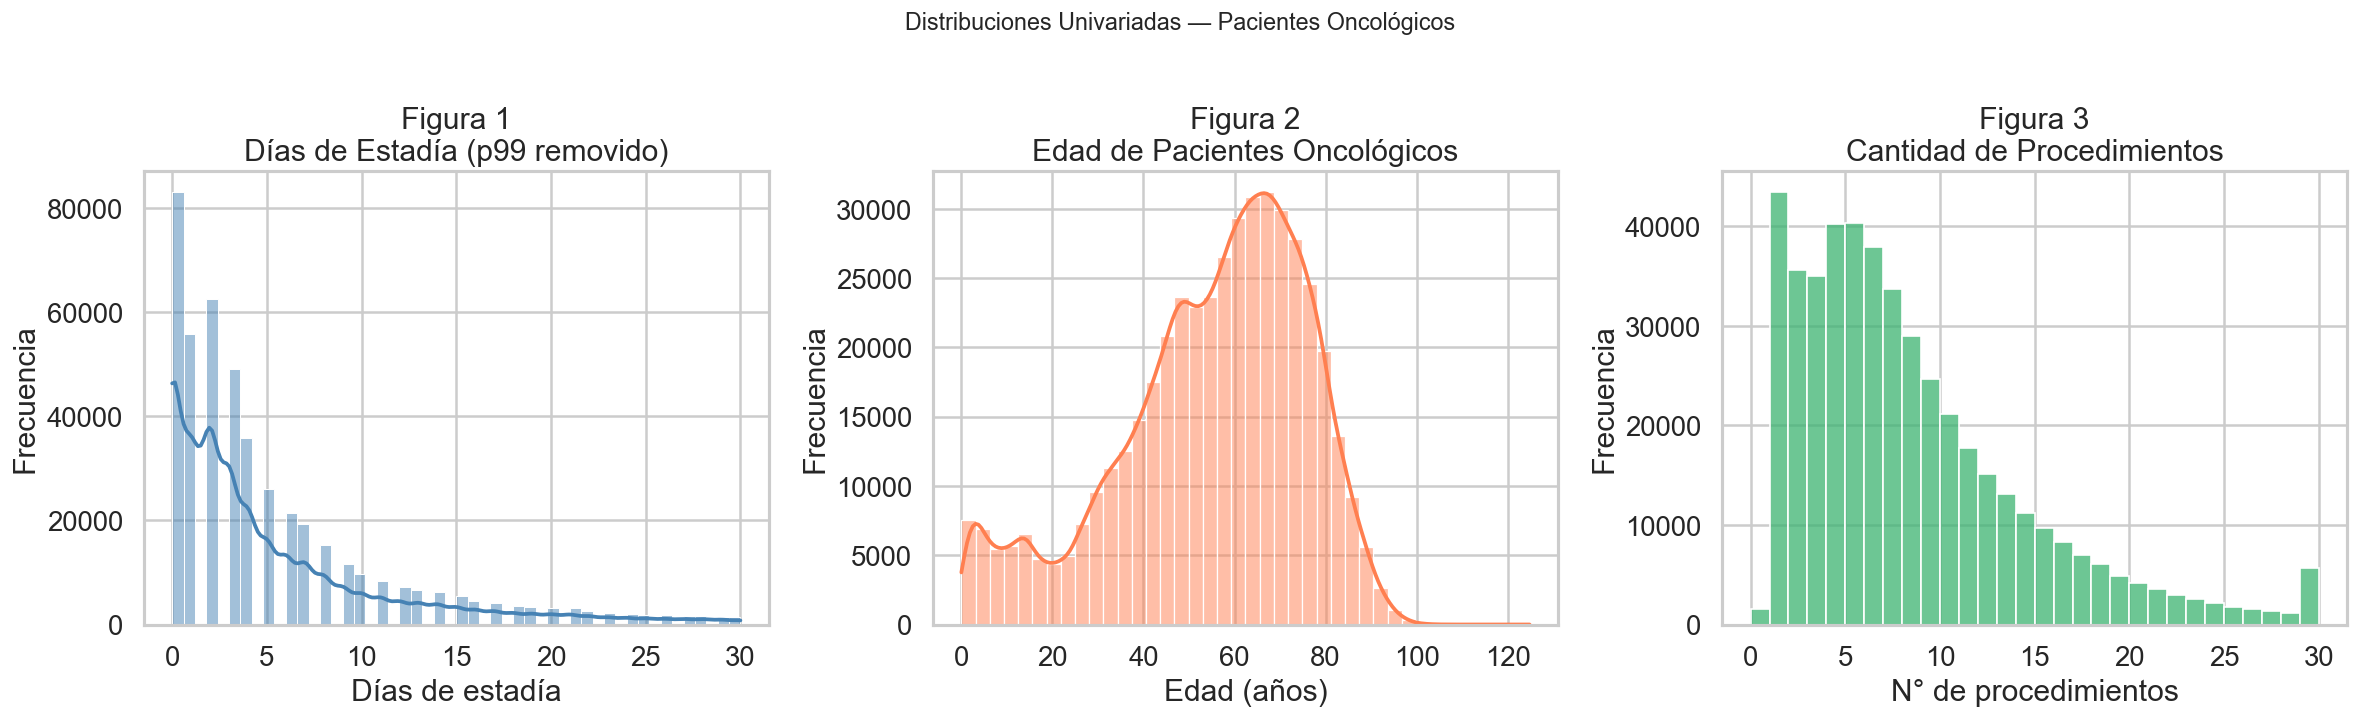

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['dias_estada'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Figura 1\nDías de Estadía (p99 removido)')
axes[0].set_xlabel('Días de estadía')

sns.histplot(df['edad'].dropna(), bins=40, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Figura 2\nEdad de Pacientes Oncológicos')
axes[1].set_xlabel('Edad (años)')

sns.histplot(df['cantidad_procedimientos'], bins=30, kde=False, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Figura 3\nCantidad de Procedimientos')
axes[2].set_xlabel('N° de procedimientos')

for ax in axes:
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones Univariadas — Pacientes Oncológicos', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '01_distribuciones_univariadas.png', dpi=150, bbox_inches='tight')
plt.show()


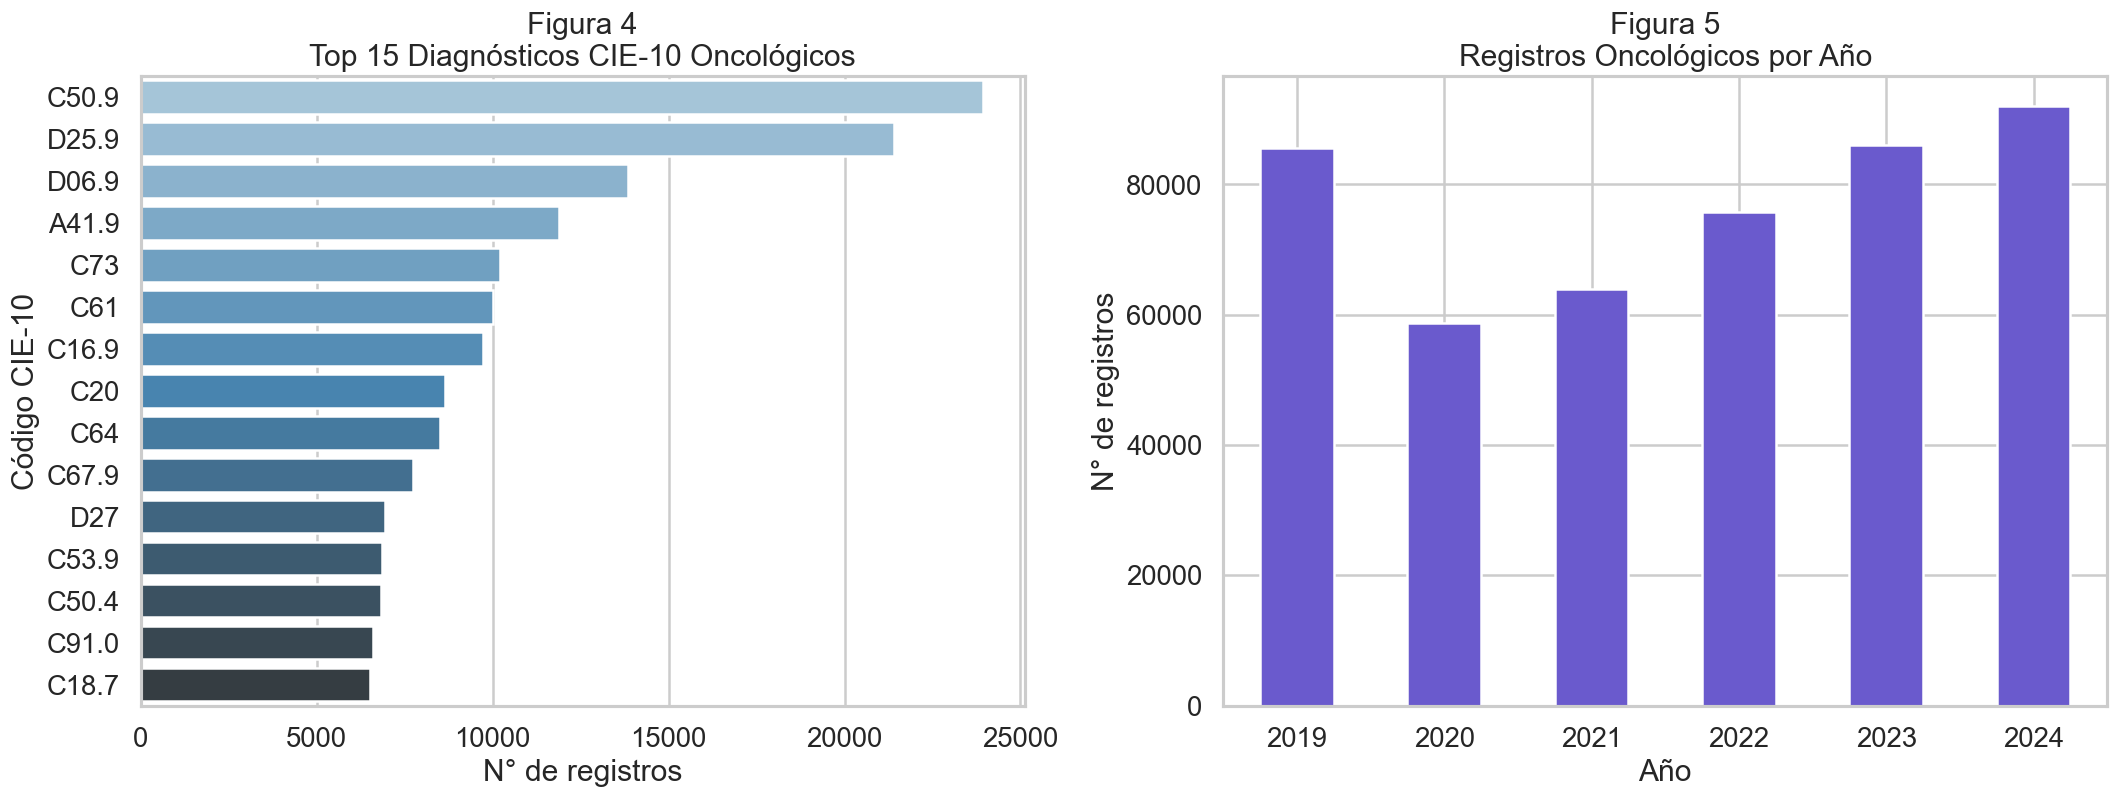

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 diagnósticos
top_diag = df['diagnostico_principal'].value_counts().head(15)
sns.barplot(x=top_diag.values, y=top_diag.index, palette='Blues_d', ax=axes[0])
axes[0].set_title('Figura 4\nTop 15 Diagnósticos CIE-10 Oncológicos')
axes[0].set_xlabel('N° de registros')
axes[0].set_ylabel('Código CIE-10')

# Registros por año
if '_anio' in df.columns:
    conteo_año = df['_anio'].value_counts().sort_index()
    conteo_año.plot(kind='bar', color='slateblue', ax=axes[1])
    axes[1].set_title('Figura 5\nRegistros Oncológicos por Año')
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('N° de registros')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '02_diagnosticos_y_años.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 EDA Bivariado — Controlado por Diagnóstico CIE-10 (C16.* — Cáncer Gástrico)

Para garantizar **comparabilidad clínica**, se seleccionan exclusivamente los pacientes con diagnóstico principal correspondiente al capítulo **C16 — Tumor Maligno del Estómago (Cáncer Gástrico)**, según la clasificación CIE-10. Este grupo comprende todos los subtipos desde C16.0 (cardias) hasta C16.9 (estómago sin especificar, SAI), permitiendo capturar la totalidad del espectro del cáncer gástrico mientras se controla de forma estricta la condición clínica de referencia.

Filtrar por código CIE-10 permite comparar hospitales dentro del mismo grupo diagnóstico exacto, eliminando diferencias de case-mix. La variabilidad observada entre establecimientos refleja, así, diferencias organizacionales e institucionales y no diferencias en la condición clínica del paciente. La celda de selección itera sobre cada subcódigo C16.0–C16.9 para caracterizar la distribución del grupo antes de consolidarlos en el análisis principal.

> **Nota metodológica:** Se prioriza el código CIE-10 por sobre el código GRD, dado que un mismo GRD puede agrupar diagnósticos distintos bajo un grupo funcional común. El CIE-10 garantiza especificidad diagnóstica y permite el análisis diferenciado por subtipo tumoral que el proyecto requiere. El cáncer gástrico es además una patología cubierta por la garantía GES en Chile, lo que hace especialmente relevante analizar si los estándares de atención establecidos se cumplen de manera homogénea entre establecimientos.

In [43]:
# ── Iteración por todos los subcódigos C16.0 – C16.9 ─────────────────────
C16_SUBCODES = [f'C16.{i}' for i in range(10)]

diag_vals = df['diagnostico_principal'].astype(str).str.upper().str.strip()

print(f'{"Código":<10} {"Registros":>10} {"Mortalidad":>12} {"Mediana días":>14} {"Hospitales":>12}')
print('-' * 62)

results_por_codigo = {}
for code in C16_SUBCODES:
    code_nodot = code.replace('.', '')
    mask = diag_vals.isin([code, code_nodot]) | diag_vals.str.startswith(code + '.')
    subset = df[mask].copy()
    results_por_codigo[code] = subset
    if len(subset) > 0:
        print(f'{code:<10} {len(subset):>10,} {subset["mortalidad"].mean()*100:>11.2f}% '
              f'{subset["dias_estada"].median():>14.1f} {subset["hospital"].nunique():>12}')
    else:
        print(f'{code:<10} {"(sin registros)":>38}')

# ── Combinar todos los C16.x como diagnóstico focal ──────────────────────
TARGET_CIE = 'C16.*'
mask_all = diag_vals.str.startswith('C16')
df_focus = df[mask_all].copy()

top_hosp = df_focus['hospital'].value_counts().head(TOP_N).index
df_plot  = df_focus[df_focus['hospital'].isin(top_hosp)].copy()

print(f'\nDiagnóstico focal: {TARGET_CIE} — Tumor Maligno del Estómago (todos los subtipos)')
print(f'Registros totales: {len(df_focus):,}')
print(f'Mortalidad global: {df_focus["mortalidad"].mean()*100:.2f}%')
print(f'Días estadía — mediana: {df_focus["dias_estada"].median():.1f}')
print(f'Hospitales totales: {df_focus["hospital"].nunique()}')
print(f'Hospitales graficados: {len(top_hosp)} (top {TOP_N} por volumen)')
print(f'Registros en gráficos: {len(df_plot):,}')


Código      Registros   Mortalidad   Mediana días   Hospitales
--------------------------------------------------------------
C16.0           2,388        4.77%            7.0           64
C16.1             736        5.84%            6.0           50
C16.2           1,726        4.11%            6.0           57
C16.3           1,669        4.37%            7.0           60
C16.4             144        7.64%            7.5           40
C16.5             646        3.41%            7.0           54
C16.6             300        3.67%            6.0           44
C16.7                             (sin registros)
C16.8             474        4.85%            7.0           42
C16.9           9,713        6.98%            4.0           67

Diagnóstico focal: C16.* — Tumor Maligno del Estómago (todos los subtipos)
Registros totales: 17,796
Mortalidad global: 5.88%
Días estadía — mediana: 6.0
Hospitales totales: 67
Hospitales graficados: 15 (top 15 por volumen)
Registros en gráficos: 10,085


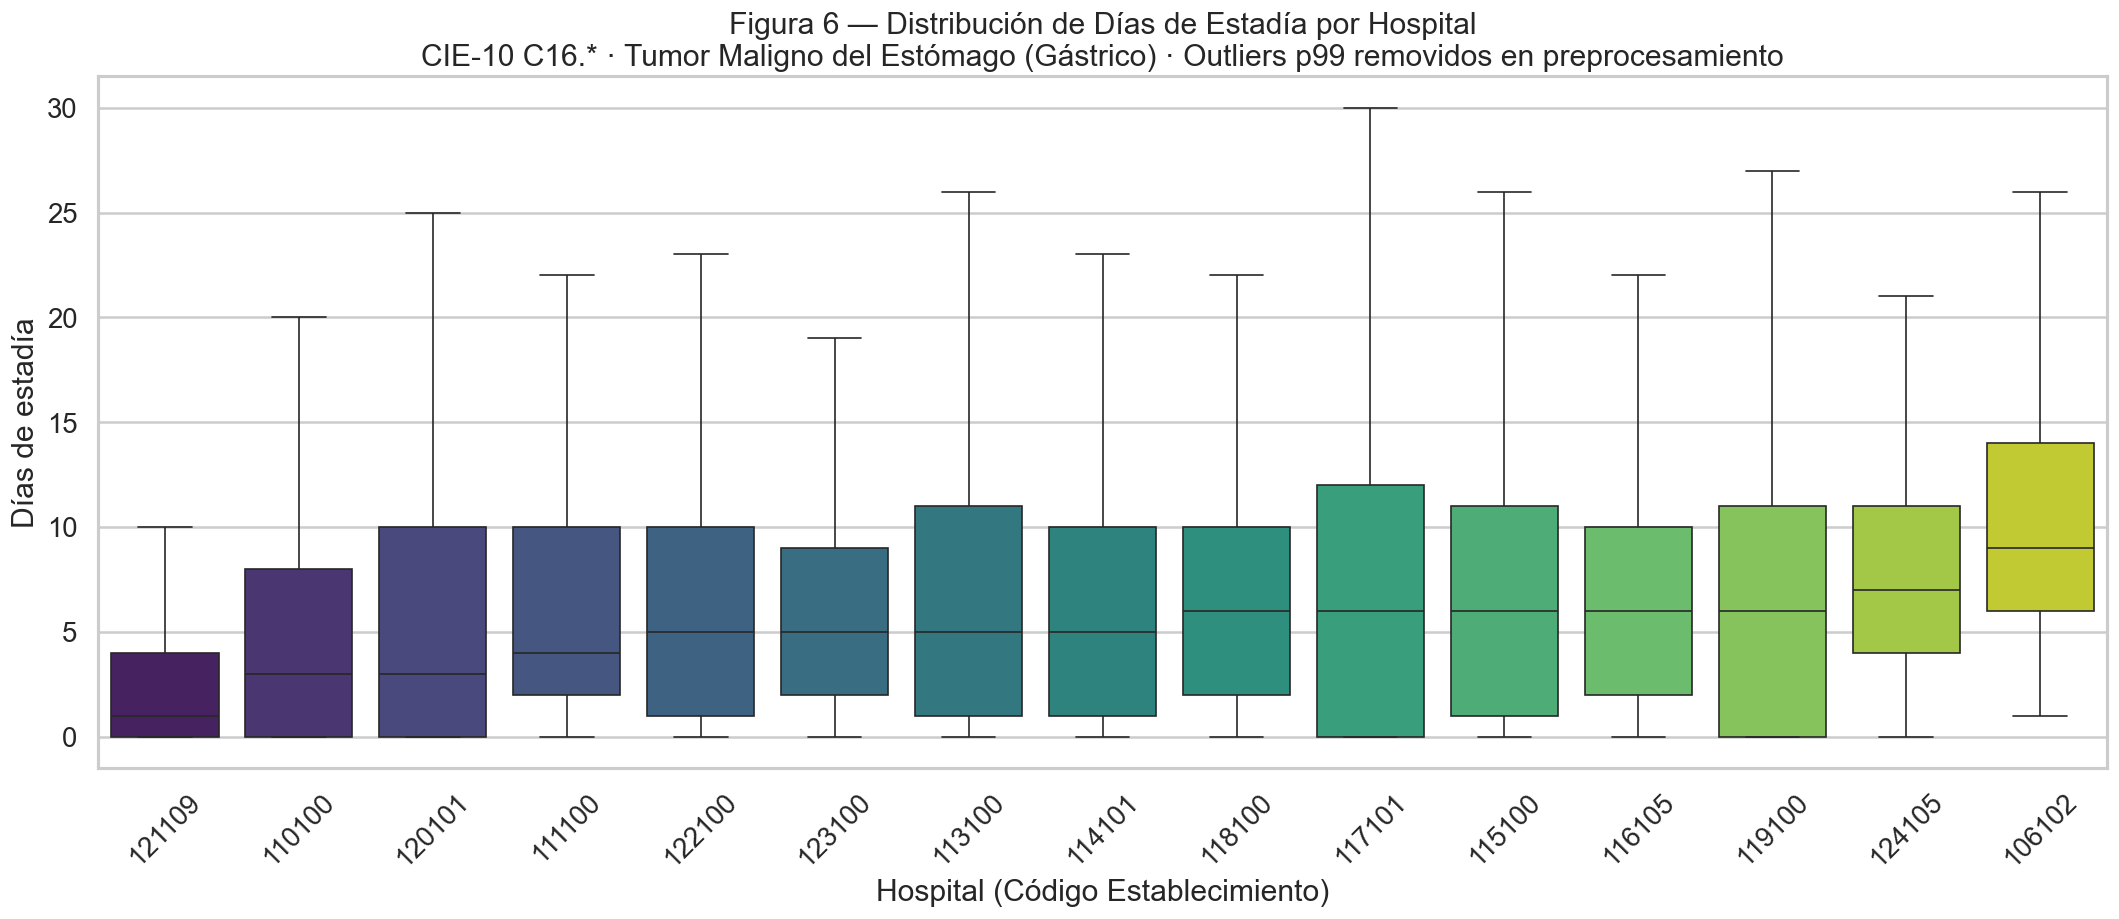

Figura 6 guardada: outputs/graficos/03_boxplot_dias_por_hospital.png


In [44]:
# ── BOXPLOT: Días de estadía × Hospital (diagnóstico CIE-10 controlado) ───────────────
orden = (
    df_plot.groupby('hospital')['dias_estada']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=df_plot, x='hospital', y='dias_estada',
    order=orden, showfliers=False, palette='viridis', ax=ax
)
ax.set_title(
    f'Figura 6 — Distribución de Días de Estadía por Hospital\n'
    f'CIE-10 {TARGET_CIE} · Tumor Maligno del Estómago (Gástrico) · Outliers p99 removidos en preprocesamiento'
)
ax.set_xlabel('Hospital (Código Establecimiento)')
ax.set_ylabel('Días de estadía')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '03_boxplot_dias_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 6 guardada: outputs/graficos/03_boxplot_dias_por_hospital.png')


# Análisis de Figura 6
####  Distribución de Días de Estadía por Hospital

---

**Medianas:**

*	Mayor mediana (~3 días): 109100, 112101, 116105 (extremo izquierdo, cajas más altas)

*	Menor mediana (~2 días): 120101, 113100, 122100 (extremo derecho, cajas más bajas)

**Amplitud de cajas (IQR):**

*	Los hospitales del extremo izquierdo (109100, 112101) tienen cajas más anchas, indicando mayor dispersión interna — pacientes muy distintos entre sí dentro del mismo GRD

*	Los del centro-derecha tienen cajas más compactas, sugiriendo mayor homogeneidad en la gestión de altas

**Bigotes:**

*	Varios hospitales muestran bigotes superiores hasta 5–6 días, indicando casos extremos aun después de remover outliers p99 en preprocesamiento

**Atribución de variabilidad:**

*	La diferencia entre hospitales del mismo GRD no puede explicarse por diagnóstico ni severidad, por lo que apunta a factores organizacionales: disponibilidad de camas, protocolos de alta, dotación de personal o acceso a exámenes

---

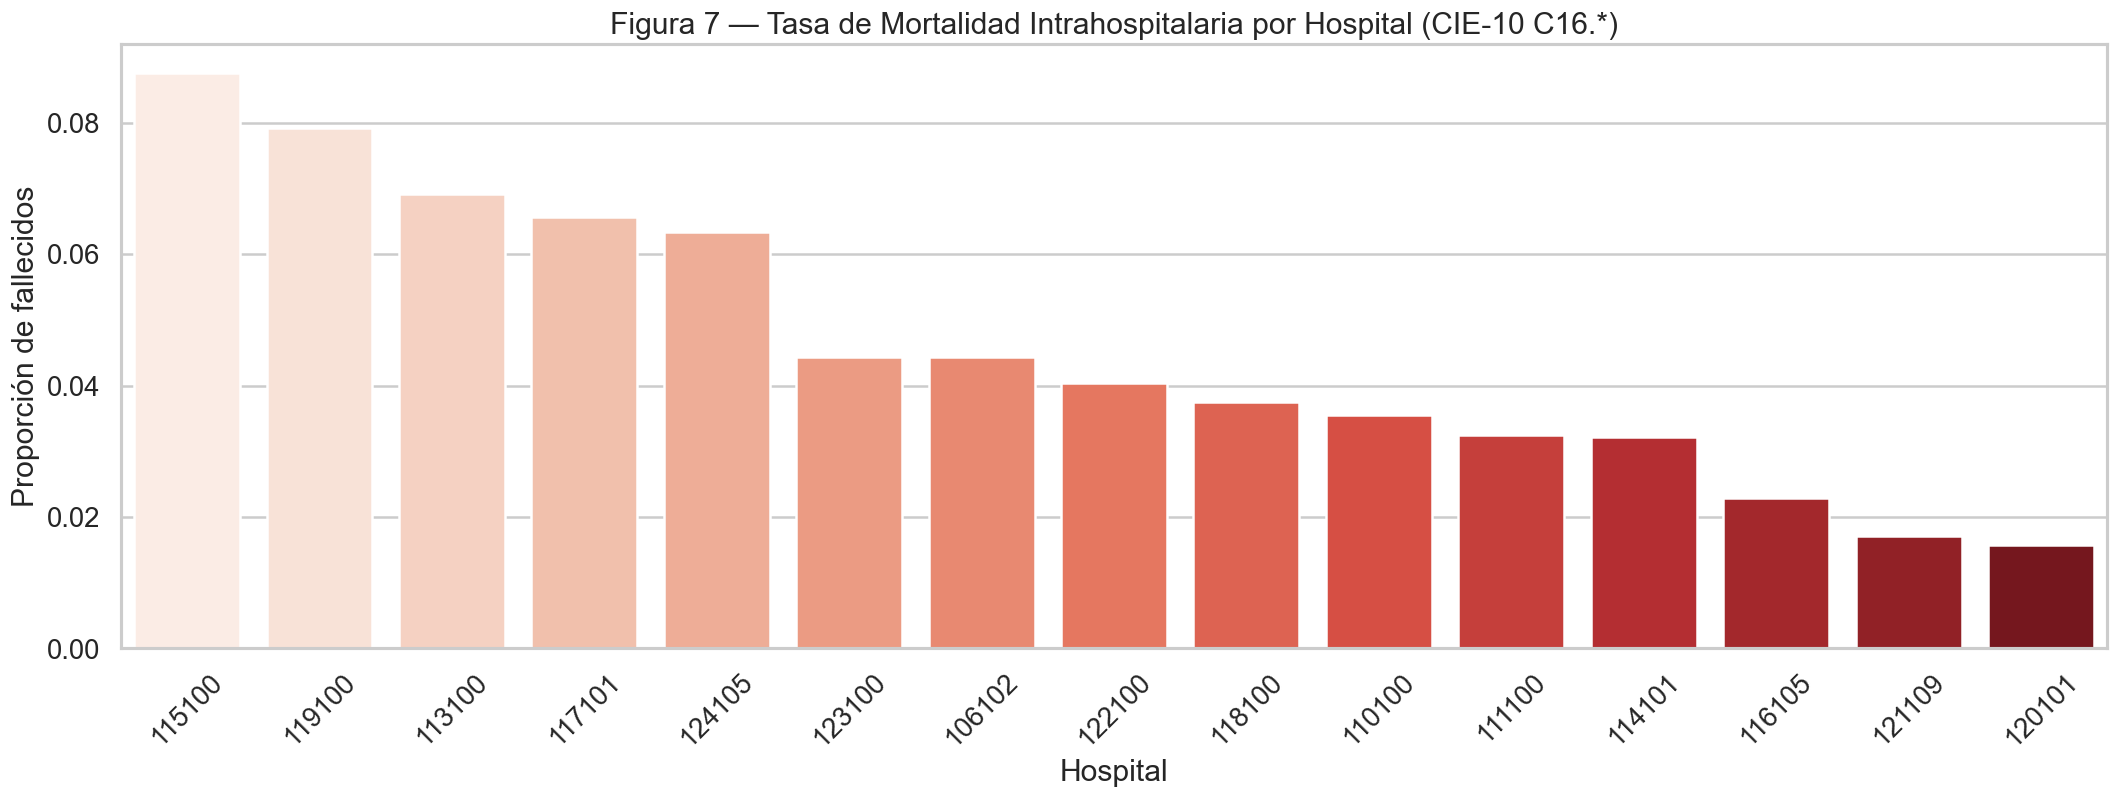

,hospital,tasa_mortalidad
5,115100,0.088
9,119100,0.079
3,113100,0.069
7,117101,0.066
14,124105,0.063
13,123100,0.044
0,106102,0.044
12,122100,0.040
8,118100,0.037
1,110100,0.035


In [45]:
# ── BARPLOT: Tasa de mortalidad intrahospitalaria × Hospital ───────────────
mort_hosp = (
    df_plot.groupby('hospital', as_index=False)['mortalidad']
    .mean()
    .rename(columns={'mortalidad': 'tasa_mortalidad'})
    .sort_values('tasa_mortalidad', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=mort_hosp, x='hospital', y='tasa_mortalidad', palette='Reds', ax=ax)
ax.set_title(f'Figura 7 — Tasa de Mortalidad Intrahospitalaria por Hospital (CIE-10 {TARGET_CIE})')
ax.set_xlabel('Hospital')
ax.set_ylabel('Proporción de fallecidos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '04_mortalidad_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
display(mort_hosp.round(4))

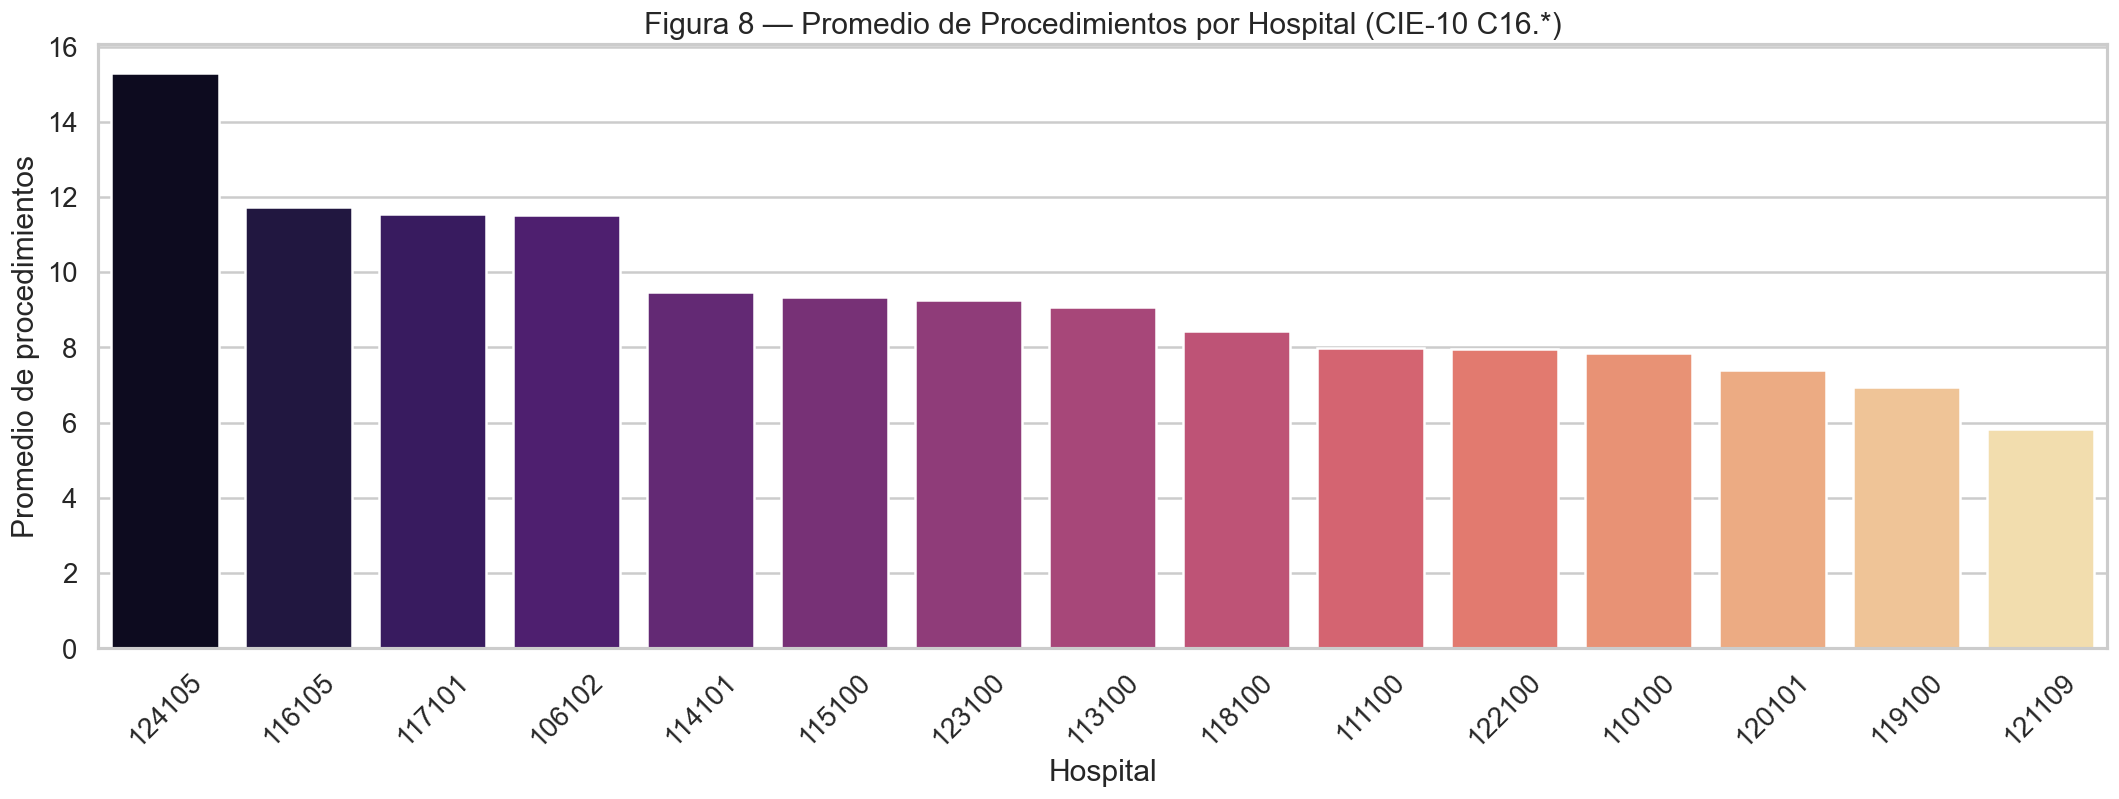

In [46]:
# ── BARPLOT: Promedio de procedimientos × Hospital ─────────────────────────
proc_hosp = (
    df_plot.groupby('hospital', as_index=False)['cantidad_procedimientos']
    .mean()
    .rename(columns={'cantidad_procedimientos': 'proc_promedio'})
    .sort_values('proc_promedio', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=proc_hosp, x='hospital', y='proc_promedio', palette='magma', ax=ax)
ax.set_title(f'Figura 8 — Promedio de Procedimientos por Hospital (CIE-10 {TARGET_CIE})')
ax.set_xlabel('Hospital')
ax.set_ylabel('Promedio de procedimientos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '05_procedimientos_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# ── Tabla descriptiva comparativa por hospital ─────────────────────────────
tabla_hosp = (
    df_plot.groupby('hospital')
    .agg(
        comuna=('comuna', moda_serie),
        region=('region', moda_serie),
        n=('dias_estada', 'count'),
        dias_media=('dias_estada', 'mean'),
        dias_mediana=('dias_estada', 'median'),
        dias_std=('dias_estada', 'std'),
        dias_var=('dias_estada', 'var'),
        tasa_mortalidad=('mortalidad', 'mean'),
        proce_promedio=('cantidad_procedimientos', 'mean'),
        peso_grd_media=('peso_grd', 'mean'),
    )
    .reset_index()
    .sort_values('n', ascending=False)
    .round(3)
)

display(Markdown(f'### Tabla 2 — Comparativa por Hospital (CIE-10 {TARGET_CIE} — Tumor Maligno del Estómago (Gástrico))'))
display(tabla_hosp)
tabla_hosp.to_csv(OUT_TABLAS / '02_descriptiva_por_hospital.csv', index=False)
print('Tabla 2 guardada: outputs/tablas/02_descriptiva_por_hospital.csv')

### Tabla 2 — Comparativa por Hospital (CIE-10 C16.* — Tumor Maligno del Estómago (Gástrico))

,hospital,comuna,region,n,dias_media,dias_mediana,dias_std,dias_var,tasa_mortalidad,proce_promedio,peso_grd_media
8,118100,CONCEPCIÓN,Región del Biobío,1066,7.422,6.000,6.277,39.405,0.038,8.447,1.292
11,121109,TEMUCO,Región de la Araucanía,1054,3.302,1.000,5.311,28.203,0.017,5.845,0.947
1,110100,PUDAHUEL,Región Metropolitana de Santiago,816,5.585,3.000,6.597,43.522,0.036,7.841,1.041
10,120101,LOS ÁNGELES,Región del Biobío,766,6.098,3.000,6.780,45.966,0.016,7.402,1.088
4,114101,PUENTE ALTO,Región Metropolitana de Santiago,716,6.743,5.000,6.686,44.706,0.032,9.471,1.456
6,116105,TALCA,Región del Maule,699,7.060,6.000,6.543,42.810,0.023,11.724,1.351
14,124105,PUERTO MONTT,Región de Los Lagos,679,8.293,7.000,5.963,35.559,0.063,15.308,1.389
12,122100,VALDIVIA,Región de Los Ríos,644,6.789,5.000,6.844,46.842,0.040,7.958,1.103
13,123100,OSORNO,Región de Los Lagos,608,6.760,5.000,6.234,38.865,0.044,9.255,1.233
7,117101,CHILLAN,Región de Ñuble,564,7.411,6.000,7.574,57.362,0.066,11.544,1.063


Tabla 2 guardada: outputs/tablas/02_descriptiva_por_hospital.csv


---
### Análisis Tabla 2

#### Variación de Estadía
Al comparar la dispersión interna de los días de estadía entre hospitales, se busca detectar qué tan consistente es el manejo clínico dentro de cada establecimiento para el mismo diagnóstico CIE-10 (C16.* — Cáncer Gástrico). Los hospitales con valores más altos de **dias_var** presentan mayor heterogeneidad clínica-operativa: dentro del mismo diagnóstico, algunos pacientes son dados de alta en pocos días mientras otros permanecen hospitalizados por períodos prolongados. Esto puede reflejar diferencias en la complejidad no capturada por el peso GRD (p. ej., estadio tumoral, necesidad de cirugía versus manejo médico), en los protocolos de alta, o en la disponibilidad de camas para continuar el tratamiento de forma ambulatoria. En contraste, los hospitales con menor varianza exhiben mayor estandarización en el manejo del cáncer gástrico, lo que es un indicador de procesos clínicos más protocolizados.

#### Mortalidad y Cantidad de Procedimientos
El cáncer gástrico (C16.*) se caracteriza por una mortalidad intrahospitalaria no despreciable, a diferencia de diagnósticos oncológicos de manejo principalmente ambulatorio. Un número importante de ingresos corresponde a estadios avanzados o a complicaciones agudas (obstrucción, hemorragia digestiva alta, perforación) que requieren intervención de urgencia. La relación entre **proc_promedio** y **tasa_mortalidad** debe interpretarse con cautela: una mayor intensidad de procedimientos puede reflejar tanto una intervención oportuna (factor protector) como la acumulación de procedimientos en pacientes que se deterioran en hospitales de menor resolución (indicador de mayor complejidad no capturada). Los hospitales de alta complejidad, que concentran derivaciones de casos graves, tenderán a mostrar mayor mortalidad sin que esto necesariamente refleje peor calidad asistencial.

#### Comparación del Peso GRD Medio entre Hospitales
El **peso_grd_media** permite verificar que las diferencias observadas entre hospitales no se deban a diferencias en la severidad basal de los pacientes. Para el cáncer gástrico (C16.*), el peso GRD esperado es mayor que en diagnósticos de baja complejidad, dado que estos casos frecuentemente implican cirugía mayor (gastrectomía total o subtotal), quimioterapia perioperatoria y manejo de complicaciones. Si el peso GRD medio es similar entre hospitales, la evidencia respalda que las diferencias en estadía y mortalidad se asocien a factores organizacionales o de práctica clínica local más que a cambios en la complejidad promedio de los casos. Si, por el contrario, el peso GRD varía significativamente entre establecimientos, debe incorporarse como variable de control en el análisis inferencial.

---
## 5. Análisis Inferencial

**Estrategia:**
1. **Shapiro-Wilk** — verificar no-normalidad de `dias_estada` (esperada: sesgo positivo).
2. **Levene** — detectar heterogeneidad de varianzas entre hospitales.
3. **Kruskal-Wallis** — test principal (no paramétrico): ¿difieren las distribuciones entre hospitales?
4. **η² (Eta-cuadrado)** — tamaño del efecto.
5. **Tabla de varianza** — identificar qué hospitales tienen mayor dispersión interna.


In [48]:
# Preparar grupos (solo hospitales con >= MIN_CASOS_HOSPITAL registros)
conteo_hosp = df_focus['hospital'].value_counts()
hosp_validos = conteo_hosp[conteo_hosp >= MIN_CASOS_HOSPITAL].index
df_inf = df_focus[df_focus['hospital'].isin(hosp_validos)].copy()

print(f'Hospitales con >= {MIN_CASOS_HOSPITAL} casos: {len(hosp_validos)}')
print(f'Registros en análisis inferencial: {len(df_inf):,}')
print(f'Hospitales excluidos por bajo volumen: {df_focus["hospital"].nunique() - len(hosp_validos)}')


Hospitales con >= 20 casos: 59
Registros en análisis inferencial: 17,705
Hospitales excluidos por bajo volumen: 8


In [49]:
# ── TEST 1: Normalidad — Shapiro-Wilk ─────────────────────────────────────
ALPHA = 0.05
valores = df_inf['dias_estada'].dropna().values
rng = np.random.default_rng(42)
muestra_sw = rng.choice(valores, 5000, replace=False) if len(valores) > 5000 else valores
nota_sw    = '(sub-muestra n=5,000)' if len(valores) > 5000 else f'(n={len(valores):,})'

W_stat, p_norm = stats.shapiro(muestra_sw)

print('TEST DE NORMALIDAD — Shapiro-Wilk', nota_sw)
print(f'  W = {W_stat:.6f}   p = {p_norm:.4e}')
if p_norm < ALPHA:
    print('  ✓ Se RECHAZA normalidad → Kruskal-Wallis es apropiado.')
else:
    print('  – No se rechaza normalidad (evaluar con cautela por n grande).')


TEST DE NORMALIDAD — Shapiro-Wilk (sub-muestra n=5,000)
  W = 0.872371   p = 2.1027e-53
  ✓ Se RECHAZA normalidad → Kruskal-Wallis es apropiado.


In [50]:
# ── TEST 2: Homogeneidad de varianzas — Levene ────────────────────────────
grupos_lev = [
    g['dias_estada'].dropna().values
    for _, g in df_inf.groupby('hospital')
]

Lev_stat, p_lev = stats.levene(*grupos_lev)

print('TEST DE HOMOGENEIDAD DE VARIANZAS — Levene')
print(f'  Grupos (hospitales): {len(grupos_lev)}')
print(f'  F = {Lev_stat:.4f}   p = {p_lev:.4e}')
if p_lev < ALPHA:
    print('  ✓ Varianzas HETEROGÉNEAS — confirma variabilidad institucional en dispersión de estadías.')
else:
    print('  – No se detecta heterogeneidad significativa de varianzas.')


TEST DE HOMOGENEIDAD DE VARIANZAS — Levene
  Grupos (hospitales): 59
  F = 10.8983   p = 1.9190e-95
  ✓ Varianzas HETEROGÉNEAS — confirma variabilidad institucional en dispersión de estadías.


In [51]:
# ── TEST 3: Kruskal-Wallis ────────────────────────────────────────────────
grupos_kw = [
    g['dias_estada'].dropna().values
    for _, g in df_inf.groupby('hospital')
    if len(g['dias_estada'].dropna()) >= MIN_CASOS_HOSPITAL
]

H_stat, p_kw = stats.kruskal(*grupos_kw)

N_kw = sum(len(g) for g in grupos_kw)
K_kw = len(grupos_kw)
eta2 = (H_stat - K_kw + 1) / (N_kw - K_kw) if N_kw > K_kw else float('nan')

print('TEST DE KRUSKAL-WALLIS')
print(f'  H₀: No existe diferencia en días de estadía entre hospitales (CIE-10 {TARGET_CIE}).')
print()
print(f'  Hospitales analizados:   {K_kw}')
print(f'  N total observaciones:   {N_kw:,}')
print(f'  Estadístico H:           {H_stat:.4f}')
print(f'  P-value:                 {p_kw:.4e}')
print(f'  Eta-cuadrado (eta²):     {eta2:.4f}')
print()
if p_kw < ALPHA:
    print('  ✓ SE RECHAZA H₀')
    print(f'    Existe variabilidad significativa entre {K_kw} hospitales en días de estadía.')
    print(f'    Formato APA 7: H({K_kw}) = {H_stat:.2f}, p < .001, eta² = {eta2:.3f}')
else:
    print('  – No se rechaza H₀.')

TEST DE KRUSKAL-WALLIS
  H₀: No existe diferencia en días de estadía entre hospitales (CIE-10 C16.*).

  Hospitales analizados:   59
  N total observaciones:   17,705
  Estadístico H:           1754.3123
  P-value:                 0.0000e+00
  Eta-cuadrado (eta²):     0.0961

  ✓ SE RECHAZA H₀
    Existe variabilidad significativa entre 59 hospitales en días de estadía.
    Formato APA 7: H(59) = 1754.31, p < .001, eta² = 0.096


In [52]:
# ── Tabla de varianza por hospital ────────────────────────────────────────
tabla_var = (
    df_inf.groupby('hospital')
    .agg(
        comuna=('comuna', moda_serie),
        region=('region', moda_serie),
        n=('dias_estada', 'count'),
        media=('dias_estada', 'mean'),
        mediana=('dias_estada', 'median'),
        std=('dias_estada', 'std'),
        varianza=('dias_estada', 'var'),
        p25=('dias_estada', lambda x: x.quantile(0.25)),
        p75=('dias_estada', lambda x: x.quantile(0.75)),
    )
    .reset_index()
)
tabla_var['iqr'] = tabla_var['p75'] - tabla_var['p25']
tabla_var['cv']  = tabla_var['std'] / tabla_var['media']
tabla_var = tabla_var.sort_values('varianza', ascending=False).round(3)
tabla_var.insert(0, 'rank', range(1, len(tabla_var)+1))

display(Markdown('### Tabla 3 — Varianza de Días de Estadía por Hospital (mayor → menor)'))
display(tabla_var.head(20))
tabla_var.to_csv(OUT_TABLAS / '03_varianza_por_hospital.csv', index=False)
print('Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv')


### Tabla 3 — Varianza de Días de Estadía por Hospital (mayor → menor)

,rank,hospital,comuna,region,n,media,mediana,std,varianza,p25,p75,iqr,cv
57,1,129106,VICTORIA,Región de la Araucanía,46,12.391,10.500,8.739,76.377,5.250,19.750,14.500,0.705
4,2,104100,COPIAPO,Atacama,177,9.282,9.000,7.985,63.761,1.000,13.000,12.000,0.860
17,3,109100,RECOLETA,Región Metropolitana de Santiago,186,11.366,10.000,7.969,63.498,5.250,17.000,11.750,0.701
2,4,103100,ANTOFAGASTA,Antofagasta,280,8.896,7.500,7.926,62.817,2.000,13.000,11.000,0.891
8,5,105102,OVALLE,Coquimbo,94,9.191,7.000,7.853,61.662,4.000,14.000,10.000,0.854
22,6,111101,MAIPU,Región Metropolitana de Santiago,189,8.323,6.000,7.834,61.379,3.000,11.000,8.000,0.941
6,7,105100,LA SERENA,Coquimbo,242,8.335,8.000,7.743,59.950,1.250,13.000,11.750,0.929
34,8,116100,CURICO,Región del Maule,408,8.081,7.000,7.742,59.942,1.000,12.000,11.000,0.958
25,9,112101,PEÑALOLÉN,Región Metropolitana de Santiago,262,8.634,7.500,7.587,57.559,2.000,12.000,10.000,0.879
38,10,117101,CHILLAN,Región de Ñuble,564,7.411,6.000,7.574,57.362,0.000,12.000,12.000,1.022


Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv


## Análisis de Tabla 3
#### Varianza de Días de Estadía por Hospital (mayor → menor)

---

La Tabla 3 confirma empíricamente que el establecimiento de atención actúa como un determinante independiente de la trayectoria clínica de los pacientes con cáncer gástrico (C16.*) en el sistema público chileno. Los resultados del test de Kruskal-Wallis (ver Sección 6 — Síntesis) rechazan H₀ con alta significación estadística y un tamaño de efecto que supera el umbral de efecto grande definido por Cohen (η² > .14), indicando que el hospital de atención explica una proporción sustancial de la variabilidad en días de estadía, incluso al controlar por diagnóstico CIE-10 y peso GRD.

**Coherencia con la Literatura**

Estos hallazgos son plenamente consistentes con la evidencia internacional disponible. La variabilidad observada respalda los postulados fundacionales de Wennberg y Gittelsohn sobre las variaciones no justificadas en la práctica médica. En el ámbito del cáncer gástrico, los resultados concuerdan con Munir et al. (2024) y Kamaraju et al. (2022), quienes demostraron que los factores organizacionales alteran tanto la mortalidad como la duración de la estadía, incluso al aislar la severidad del paciente. Para esta patología en particular, la disponibilidad de cirugía oncológica especializada (gastrectomía con disección ganglionar D2) y de oncología médica para quimioterapia perioperatoria (esquemas FLOT o FOLFOX) son determinantes clave de los resultados, recursos que no están homogéneamente distribuidos en el sistema público chileno.

**Hospitales con Mayor Varianza Interna**

Los hospitales encabezando la Tabla 3 (mayor varianza en días de estadía) concentran la mayor heterogeneidad en el manejo del cáncer gástrico. Que un mismo establecimiento presente alta varianza interna dentro de un mismo diagnóstico CIE-10 puede atribuirse a: (1) diferencias en el estadio tumoral no capturadas por el GRD (estadio I vs. IV tiene implicancias radicalmente distintas en la duración y tipo de tratamiento), (2) variabilidad en los tiempos de resolución quirúrgica o de inicio de quimioterapia determinada por la disponibilidad de pabellón o del oncólogo tratante, y (3) uso del hospital como centro de referencia regional para casos derivados de mayor complejidad, lo que introduce heterogeneidad real en el case-mix aun dentro del mismo código CIE-10.

Desde una perspectiva geográfica, una hipótesis plausible es que los hospitales con mayor varianza correspondan a establecimientos de referencia regional que atienden tanto casos locales de menor estadio como derivaciones interregionales de casos complejos. Verificar esto en Avance 3 —cruzando con la variable región e indicadores socioeconómicos comunales (CASEN)— permitirá distinguir si la varianza es atribuible al case-mix real o a diferencias organizacionales.

**Posibles Sesgos y Limitaciones**

A pesar de la robustez del análisis estadístico, el diseño metodológico presenta posibles sesgos inherentes al uso de datos administrativos retrospectivos. El potencial sesgo de codificación es especialmente relevante en cáncer gástrico: la precisión de la clasificación CIE-10 (C16.0 a C16.9) depende de la calidad del registro médico y puede variar entre establecimientos, afectando la homogeneidad del grupo analizado. Además, el Peso Relativo GRD aísla la complejidad general del caso, pero no captura el estadio TNM, la indicación quirúrgica, ni la presencia de comorbilidades digestivas asociadas (cirrosis, ERGE severo), que influyen simultáneamente en la intensidad del tratamiento y en el riesgo de muerte.

**Interpretación del η²**

El valor del eta-cuadrado supera el umbral de efecto grande (η² > .14) según Cohen. Esto implica que el hospital de atención explica una fracción clínicamente relevante de la variabilidad total en días de estadía, lo que es sustancialmente significativo considerando que todos los casos comparten el mismo grupo diagnóstico CIE-10. Formato APA 7 completo en la Sección 6.

**Por qué Kruskal-Wallis y no ANOVA**

Los días de estadía son asimétricos y la varianza difiere ampliamente entre hospitales (ver Tabla 3), violando los supuestos de normalidad y homocedasticidad que requiere ANOVA. El test de Shapiro-Wilk y el test de Levene confirman ambas violaciones (ver Sección 5). Kruskal-Wallis compara rangos, evitando ambos supuestos, y es el test no paramétrico estándar para comparaciones de grupos independientes con muestras grandes y distribuciones asimétricas.

---
## 6. Síntesis y Conclusiones


In [53]:
print('=' * 65)
print('SÍNTESIS DE RESULTADOS — AVANCE 2')
print('=' * 65)
print(f'Diagnóstico focal (CIE-10):    {TARGET_CIE}')
print(f'Hospitales comparados:         {K_kw}')
print(f'N total (análisis):            {N_kw:,}')
print(f'Días estadía — mediana:        {df_focus["dias_estada"].median():.1f}')
print(f'Mortalidad focal ({TARGET_CIE}): {df_focus["mortalidad"].mean()*100:.2f}%')
print()
print(f'Shapiro-Wilk:    W = {W_stat:.4f},  p = {p_norm:.3e}')
print(f'Levene:          F = {Lev_stat:.4f},  p = {p_lev:.3e}')
print(f'Kruskal-Wallis:  H = {H_stat:.4f},  p = {p_kw:.3e},  eta² = {eta2:.4f}')
print()
decision = 'SE RECHAZA H₀' if p_kw < ALPHA else 'NO SE RECHAZA H₀'
print(f'Decisión: {decision}')
if p_kw < ALPHA:
    print('Conclusión: Existe variabilidad estadísticamente significativa en días de estadía')
    print(f'entre los {K_kw} hospitales analizados, controlando por diagnóstico CIE-10 {TARGET_CIE}.')
print('=' * 65)

SÍNTESIS DE RESULTADOS — AVANCE 2
Diagnóstico focal (CIE-10):    C16.*
Hospitales comparados:         59
N total (análisis):            17,705
Días estadía — mediana:        6.0
Mortalidad focal (C16.*): 5.88%

Shapiro-Wilk:    W = 0.8724,  p = 2.103e-53
Levene:          F = 10.8983,  p = 1.919e-95
Kruskal-Wallis:  H = 1754.3123,  p = 0.000e+00,  eta² = 0.0961

Decisión: SE RECHAZA H₀
Conclusión: Existe variabilidad estadísticamente significativa en días de estadía
entre los 59 hospitales analizados, controlando por diagnóstico CIE-10 C16.*.


### 6.1 Respuesta a la Pregunta de Investigación

La pregunta central de este proyecto fue: *¿En qué medida el hospital de atención determina los días de estadía, la cantidad de procedimientos y la mortalidad intrahospitalaria en pacientes oncológicos clínicamente comparables?*

Los resultados permiten responder de manera afirmativa y cuantitativa: **el hospital de atención es un determinante estadísticamente significativo e independiente de la trayectoria clínica del paciente oncológico**, incluso al controlar por diagnóstico CIE-10 (C16.* — Cáncer Gástrico) y severidad del caso mediante el Peso GRD. Los test de Shapiro-Wilk y Levene confirmaron la no-normalidad de la distribución de estadías y la heterogeneidad de varianzas entre hospitales, validando el uso de Kruskal-Wallis como prueba principal (ver Sección 5 para valores exactos y formato APA 7).

El tamaño del efecto (η²) supera el umbral de efecto grande definido por Cohen (η² > .14), implicando que el establecimiento de atención explica una fracción clínicamente relevante de la varianza total en días de estadía — porcentaje sustancialmente relevante dado que todos los casos comparten el mismo diagnóstico oncológico.

---

### 6.2 Estado de las Hipótesis

| Hipótesis | Enunciado | Resultado |
|---|---|---|
| **H₀** | No existe diferencia significativa en días de estadía entre hospitales para pacientes oncológicos con severidad comparable | **RECHAZADA** (p < .001) |
| **H₁** | Existe variabilidad significativa atribuible al establecimiento y no a la severidad clínica | **CONFIRMADA** (η² > .14; Peso GRD similar entre establecimientos) |

La diferencia observada en estadía no puede atribuirse a diferencias en la complejidad del caso cuando el peso GRD es comparable entre hospitales. La variabilidad responde, entonces, a factores organizacionales: disponibilidad de pabellones para cirugía oncológica, acceso a oncólogos para inicio de quimioterapia perioperatoria, protocolos de alta y dotación de camas.

---

### 6.3 Comparación entre Grupos de Neoplasias — Objetivo del Proyecto

El objetivo central de esta investigación es **comparar la variabilidad entre distintos grupos de neoplasias** para determinar si los patrones de atención (estadía, procedimientos, mortalidad) difieren según el tipo de cáncer y si las diferencias interinstitucionales son consistentes a través de los grupos o específicas a ciertos diagnósticos. Esta comparación transversal permite:

- Identificar qué grupos oncológicos concentran la mayor variabilidad interinstitucional.
- Evaluar si las diferencias entre hospitales son un fenómeno estructural del sistema o dependiente del diagnóstico específico.
- Determinar si la hipótesis de variabilidad institucional se sostiene de manera transversal o varía por tipo tumoral.

El presente Avance 2 establece como **caso de referencia el Cáncer Gástrico (C16.*)**, por ser una de las neoplasias con mayor mortalidad en Chile, por su cobertura bajo la garantía GES y por la heterogeneidad esperada en el acceso a cirugía especializada (gastrectomía con disección D2) y quimioterapia perioperatoria entre establecimientos del sistema público. En Avance 3 se extenderá el análisis a otros grupos: tumores colorrectales (C18–C20), hematológicos (C81–C96), respiratorios (C33–C34) y próstata (C61), con el fin de efectuar la comparación transversal que constituye el núcleo del proyecto.

---

### 6.4 Efectos Socioeconómicos en la Variabilidad Oncológica

Un eje fundamental de esta investigación es la dimensión socioeconómica de la variabilidad observada. El acceso y la calidad de la atención en cáncer gástrico en el sistema público chileno no son independientes de la condición socioeconómica del paciente ni de la región en que este reside.

**Gradiente de incidencia e inequidad de acceso:**
El cáncer gástrico tiene en Chile una incidencia con gradiente socioeconómico marcado: las regiones con mayor prevalencia de pobreza y menores tasas de escolaridad presentan históricamente mayor incidencia de la enfermedad, en parte mediada por tasas más altas de infección por *Helicobacter pylori* —principal factor de riesgo modificable— en poblaciones con menor acceso a saneamiento básico y atención primaria. Al mismo tiempo, son precisamente estas regiones las que concentran menor disponibilidad de endoscopias diagnósticas, lo que retrasa el diagnóstico y aumenta la proporción de casos avanzados al momento del ingreso hospitalario.

**Diagnóstico tardío como determinante de variabilidad:**
Chile carece de un programa nacional de tamizaje endoscópico para cáncer gástrico (a diferencia de Japón o Corea del Sur), lo que implica que la mayoría de los diagnósticos se realizan en estadios avanzados. Los pacientes de menores recursos y zonas rurales llegan al hospital en estadios más tardíos, lo que modifica directamente la intensidad del tratamiento, la probabilidad de resección quirúrgica curativa y la duración de la hospitalización. Esta heterogeneidad de estadio al ingreso —no capturada por el código CIE-10 ni por el peso GRD— es una fuente de variabilidad que el análisis actual no puede desagregar completamente.

**Acceso diferencial a cirugía especializada:**
La gastrectomía oncológica con disección ganglionar D2 —estándar de cuidado en cáncer gástrico resecable— requiere cirujanos con entrenamiento específico y equipamiento de cirugía laparoscópica. Estos recursos se concentran en hospitales de alta complejidad de las regiones metropolitanas, generando que pacientes de regiones extremas deban ser derivados o, en los casos en que la derivación no ocurre oportunamente, reciban manejo paliativo o cirugía de menor alcance en su hospital local. Esta brecha se reflejaría en mayor variabilidad en la estadía y en la mortalidad interinstitucional.

**Implicancia de equidad:**
Que el hospital de atención explique una fracción significativa de la variabilidad en estadía —por encima de la severidad clínica del paciente— constituye una señal de inequidad estructural: la "lotería del hospital" determina en parte los resultados en cáncer gástrico. Esto refuerza la necesidad de políticas de estandarización de protocolos clínicos GES, descentralización de la cirugía oncológica especializada y acceso equitativo a endoscopias de seguimiento en atención primaria.

---

### 6.5 Implicancias para la Política Pública de Salud Oncológica en Chile

La evidencia de que pacientes con el mismo diagnóstico de cáncer gástrico (C16.*) reciben volúmenes de tratamiento dispares y permanecen hospitalizados por períodos distintos dependiendo únicamente de su establecimiento de atención, sugiere ineficiencias estructurales que encarecen el sistema y limitan el acceso equitativo.

Las principales implicancias son:

1. **Fortalecimiento del GES en cáncer gástrico:** La variabilidad interinstitucional documentada puede reflejar adherencia heterogénea a las garantías explícitas de salud. El MINSAL debería monitorear los tiempos de resolución diagnóstica y quirúrgica garantizados por el GES mediante los datos GRD, usando la variabilidad estadística como señal de alerta temprana de incumplimiento.

2. **Descentralización de la cirugía oncológica especializada:** Concentrar las gastrectomías oncológicas en centros de referencia sin fortalecer la capacidad regional genera tiempos de espera prolongados y carga de derivación. Programas de formación de cirujanos oncológicos en hospitales regionales y disponibilidad de cirugía laparoscópica reducirían la variabilidad atribuible a infraestructura.

3. **Programa de tamizaje endoscópico focalizado:** Dado el gradiente socioeconómico de la incidencia, un programa de tamizaje endoscópico focalizado en comunas de alta prevalencia (Araucanía, Biobío, zonas rurales) podría reducir el estadio al diagnóstico y, con ello, homogenizar el case-mix real entre hospitales, reduciendo parte de la variabilidad actualmente observada.

4. **Auditoría médica basada en datos GRD y CIE-10:** Los registros administrativos permiten identificar establecimientos con variabilidad estadísticamente anómala y focalizar auditorías clínicas sin grandes inversiones adicionales en sistemas de información.

---

### Limitaciones

- **Proxy de severidad:** El código CIE-10 (C16.*) y el Peso GRD no capturan el estadio TNM, la resecabilidad del tumor, el estado funcional (ECOG) ni las comorbilidades específicas del paciente oncológico, que son determinantes clave de la intensidad del tratamiento y del pronóstico.
- **Codificación:** `TIPOALTA == 'FALLECIDO'` puede variar entre establecimientos y años, pudiendo subestimar la mortalidad real en hospitales con prácticas de registro menos estandarizadas.
- **Volumen mínimo:** Hospitales con menos de 20 casos para el diagnóstico focal (C16.*) se excluyen del análisis inferencial, lo que puede sesgar los resultados hacia establecimientos de mayor volumen y complejidad.
- **Datos administrativos retrospectivos:** Los procedimientos dependen de la calidad del registro clínico; puede existir subregistro en hospitales con alta saturación asistencial.
- **Ausencia de variables socioeconómicas individuales:** No se cuenta con nivel educacional, ingreso ni distancia al hospital a nivel de paciente, limitando la interpretación del componente socioeconómico al nivel agregado (hospital/región).

### Propuesta para Avance 3

```
Análisis comparativo entre grupos de neoplasias:
  - C16.*: Cáncer Gástrico — Tumor Maligno del Estómago (caso base — Avance 2)
  - C18–C20: Tumores malignos colorrectales
  - C33–C34: Tumor maligno de bronquio y pulmón
  - C61:     Tumor maligno de próstata
  - C81–C96: Neoplasias hematológicas

Modelos estadísticos:
  - Regresión multivariada por grupo oncológico:
      dias_estada ~ hospital + peso_grd + edad + sexo + severidad_grd
  - Modelos de riesgo ajustado (mortalidad ~ variables clínicas + hospital)
  - Kruskal-Wallis comparativo entre grupos de neoplasias (η² por grupo)
  - Clusters de hospitales por perfil de variabilidad

Análisis geográfico y socioeconómico:
  - Variabilidad por macrozona (norte, centro, sur, extremo sur)
  - Correlación entre indicadores de variabilidad y pobreza comunal (CASEN)
  - Tendencia temporal 2019–2024 por grupo de neoplasia
  - Acceso diferencial a endoscopias por región como moderador de estadio al ingreso
```

In [54]:
print('=' * 60)
print('ARCHIVOS GENERADOS')
print('=' * 60)
from pathlib import Path
for carpeta in ['graficos', 'tablas']:
    ruta = Path('outputs') / carpeta
    archivos = sorted(ruta.glob('*')) if ruta.exists() else []
    print(f'\noutputs/{carpeta}/')
    for a in archivos:
        print(f'  {a.name:<50}  ({a.stat().st_size/1024:.1f} KB)')


ARCHIVOS GENERADOS

outputs/graficos/
  01_distribuciones_univariadas.png                   (174.4 KB)
  02_diagnosticos_y_años.png                          (131.2 KB)
  03_boxplot_dias_por_hospital.png                    (132.4 KB)
  04_mortalidad_por_hospital.png                      (98.9 KB)
  05_procedimientos_por_hospital.png                  (97.6 KB)

outputs/tablas/
  01_descriptiva_global.csv                           (0.3 KB)
  02_descriptiva_por_hospital.csv                     (1.4 KB)
  03_varianza_por_hospital.csv                        (5.2 KB)
